**Preprocessing Customer Dataset**

In [1]:
import numpy as np
import pandas as pd

df_customer = pd.read_csv('olist/olist_customers_dataset.csv')
df_customer.head()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

checking null values

In [2]:
df_customer.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [3]:
df_customer.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

**Preprocessing for Geolocation**

In [4]:
df_Geo=pd.read_csv('olist/olist_geolocation_dataset.csv')
df_Geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [5]:
df_Geo.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [6]:
df_Geo.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='str')

**Order Items Data Preprocessing**

In [7]:
df_OrderItems=pd.read_csv('olist/olist_order_items_dataset.csv')
df_OrderItems.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
df_OrderItems.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

**Order Payments**

In [9]:
df_OrderPayments=pd.read_csv("olist/olist_order_payments_dataset.csv")
df_OrderPayments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [10]:
df_OrderPayments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

**Order Reviews**

In [11]:
df_OrderReviews=pd.read_csv('olist/olist_order_reviews_dataset.csv')
df_OrderReviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [12]:
df_OrderReviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [13]:
df_OrderReviews[df_OrderReviews.isna()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
99219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99222,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_OrderReviews['review_comment_message'] = df_OrderReviews['review_comment_message'].fillna('no comment')
df_OrderReviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,no comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,no comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,no comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [15]:
df_OrderReviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message         0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [16]:
df_OrderReviews.drop(columns=['review_comment_title'], inplace=True)

In [17]:
df_OrderReviews.isnull().sum()


review_id                  0
order_id                   0
review_score               0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

**Order Dataset**

In [18]:
df_Order=pd.read_csv('olist/olist_orders_dataset.csv')
df_Order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
df_Order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [20]:
df_Order.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [21]:
df_Order[df_Order['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [22]:
df_Order['order_approved_at'] = pd.to_datetime(df_Order['order_approved_at'], errors='coerce')
df_Order['is_approved'] = df_Order['order_approved_at'].notna()

print(f"Unapproved orders: {(~df_Order['is_approved']).sum()}")
df_Order[['order_approved_at', 'is_approved']].head()

Unapproved orders: 160


,order_approved_at,is_approved
0,2017-10-02 11:07:15,True
1,2018-07-26 03:24:27,True
2,2018-08-08 08:55:23,True
3,2017-11-18 19:45:59,True
4,2018-02-13 22:20:29,True


In [23]:
df_Order['order_status'].unique()

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [24]:
df_Order['order_delivered_carrier_date'] = pd.to_datetime(df_Order['order_delivered_carrier_date'], errors='coerce')
df_Order['order_delivered_customer_date'] = pd.to_datetime(df_Order['order_delivered_customer_date'], errors='coerce')

print("Missing carrier date by status:")
print(df_Order[df_Order['order_delivered_carrier_date'].isna()]['order_status'].value_counts())

print("\nMissing customer delivery date by status:")
print(df_Order[df_Order['order_delivered_customer_date'].isna()]['order_status'].value_counts())


problem_rows = df_Order[
    (df_Order['order_status'] == 'delivered') &
    (df_Order['order_delivered_customer_date'].isna())
]
print(f"\nDelivered orders with missing delivery date (data quality issue): {len(problem_rows)}")

Missing carrier date by status:
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

Missing customer delivery date by status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Delivered orders with missing delivery date (data quality issue): 8


In [25]:
df_Order = df_Order[~(
    (df_Order['order_status'] == 'delivered') &
    (df_Order['order_delivered_customer_date'].isna())
)]

In [26]:
df_Order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
is_approved                         0
dtype: int64

**Product Dataset**

In [27]:
df_Product=pd.read_csv('olist/olist_products_dataset.csv')
df_Product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [28]:
df_Product.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [29]:
df_Product[df_Product['product_category_name'].isna()]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [30]:
df_Product['product_category_name'] = df_Product['product_category_name'].fillna('unknown')

df_Product['product_name_lenght'] = df_Product['product_name_lenght'].fillna(
    df_Product['product_name_lenght'].median()
)

df_Product['product_description_lenght'] = df_Product['product_description_lenght'].fillna(
    df_Product['product_description_lenght'].median()
)

In [31]:
import warnings
warnings.filterwarnings('ignore')
df_Product['product_photos_qty'].fillna(df_Product['product_photos_qty'].median(), inplace=True)

0        1.0
1        1.0
2        1.0
3        1.0
4        4.0
        ... 
32946    2.0
32947    1.0
32948    1.0
32949    2.0
32950    1.0
Name: product_photos_qty, Length: 32951, dtype: float64

In [32]:
cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']

for col in cols:
    df_Product[col] = df_Product.groupby('product_category_name')[col].transform(lambda x: x.fillna(x.median()))
df_Product.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght             0
product_description_lenght      0
product_photos_qty            610
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64

**Category Name Translation**

In [33]:
df_CategoryNameTranslation=pd.read_csv('olist/product_category_name_translation.csv')
df_CategoryNameTranslation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [34]:
df_CategoryNameTranslation.isnull().sum()   

product_category_name            0
product_category_name_english    0
dtype: int64

In [35]:
df_Seller=pd.read_csv('olist/olist_sellers_dataset.csv')
df_Seller.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [36]:
df_Seller.isnull().sum() 

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

**Storing Cleaned Data**

In [37]:
import os

folder_path = "olist_processed_data"

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

print("Folder created successfully!")
df_customer.to_csv(folder_path + "/customers_cleaned.csv")
df_Geo.to_csv(folder_path + "/geolocation_cleaned.csv")
df_OrderItems.to_csv(folder_path + "/order_items_cleaned.csv", index=False)
df_OrderPayments.to_csv(folder_path + "/order_payments_cleaned.csv", index=False)
df_OrderReviews.to_csv(folder_path + "/order_reviews_cleaned.csv", index=False)
df_Order.to_csv(folder_path + "/orders_cleaned.csv", index=False)
df_Product.to_csv(folder_path + "/products_cleaned.csv", index=False)
df_Seller.to_csv(folder_path + "/sellers_cleaned.csv", index=False)
df_CategoryNameTranslation.to_csv(folder_path + "/category_translation_cleaned.csv", index=False)

print("All DataFrames saved successfully!")


Folder created successfully!
All DataFrames saved successfully!


Installing Fakers

In [38]:
!pip install faker


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Adding augaamented files(used fakers)

In [39]:
import pandas as pd
import numpy as np
from faker import Faker
import uuid
from datetime import timedelta
import random
import os

fake = Faker('pt_BR')
np.random.seed(42)
random.seed(42)



orders_orig   = pd.read_csv('olist_processed_data/orders_cleaned.csv')
items_orig    = pd.read_csv('olist_processed_data/order_items_cleaned.csv')
payments_orig = pd.read_csv('olist_processed_data/order_payments_cleaned.csv')

product_ids = items_orig['product_id'].dropna().unique().tolist() 
seller_ids  = items_orig['seller_id'].dropna().unique().tolist()

print(f"Original orders   : {len(orders_orig)}")
print(f"Original items    : {len(items_orig)}")
print(f"Original payments : {len(payments_orig)}")



all_customers    = orders_orig['customer_id'].unique()
repeat_count     = int(len(all_customers) * 0.30)
repeat_customers = np.random.choice(all_customers, size=repeat_count, replace=False)

print(f"\nTotal unique customers       : {len(all_customers)}")
print(f"Selected for repeat orders   : {repeat_count} (30%)")




reference_date = pd.to_datetime(orders_orig['order_purchase_timestamp']).max()

new_orders   = []
new_items    = []
new_payments = []

for customer_id in repeat_customers:
    num_extra_orders = random.choices([1, 2], weights=[0.7, 0.3])[0]

    for _ in range(num_extra_orders):
        new_order_id = str(uuid.uuid4()).replace('-', '')

    
        days_ago     = random.randint(1, 365)
        purchase_ts  = reference_date - timedelta(days=days_ago)
        approved_ts  = purchase_ts  + timedelta(hours=random.randint(1, 24))
        carrier_ts   = approved_ts  + timedelta(days=random.randint(1, 5))
        delivery_ts  = carrier_ts   + timedelta(days=random.randint(3, 15))
        estimated_ts = carrier_ts   + timedelta(days=random.randint(10, 20))

        new_orders.append({
            'order_id'                      : new_order_id,
            'customer_id'                   : customer_id,
            'order_status'                  : 'delivered',
            'order_purchase_timestamp'      : purchase_ts,
            'order_approved_at'             : approved_ts,
            'order_delivered_carrier_date'  : carrier_ts,
            'order_delivered_customer_date' : delivery_ts,
            'order_estimated_delivery_date' : estimated_ts,
        })
        num_items   = random.randint(1, 3)
        total_price = 0

        for item_seq in range(1, num_items + 1):
            price         = round(random.uniform(20, 500), 2)
            freight_value = round(random.uniform(5, 50), 2)
            total_price  += price + freight_value

            new_items.append({
                'order_id'           : new_order_id,
                'order_item_id'      : item_seq,
                'product_id'         : random.choice(product_ids),
                'seller_id'          : random.choice(seller_ids),
                'shipping_limit_date': carrier_ts + timedelta(days=2),
                'price'              : price,
                'freight_value'      : freight_value,
            })

        payment_type = random.choices(
            ['credit_card', 'boleto', 'voucher', 'debit_card'],
            weights=[0.6, 0.2, 0.1, 0.1]
        )[0]

        new_payments.append({
            'order_id'             : new_order_id,
            'payment_sequential'   : 1,
            'payment_type'         : payment_type,
            'payment_installments' : random.randint(1, 6) if payment_type == 'credit_card' else 1,
            'payment_value'        : round(total_price, 2),
        })

print(f"\nSynthetic orders generated   : {len(new_orders)}")
print(f"Synthetic items generated    : {len(new_items)}")
print(f"Synthetic payments generated : {len(new_payments)}")

orders_augmented   = pd.concat([orders_orig,   pd.DataFrame(new_orders)],   ignore_index=True)
items_augmented    = pd.concat([items_orig,    pd.DataFrame(new_items)],    ignore_index=True)
payments_augmented = pd.concat([payments_orig, pd.DataFrame(new_payments)], ignore_index=True)

print(f"\nAugmented orders   : {len(orders_augmented)}")
print(f"Augmented items    : {len(items_augmented)}")
print(f"Augmented payments : {len(payments_augmented)}")



os.makedirs('olist_augmented_data', exist_ok=True)

orders_augmented.to_csv('olist_augmented_data/orders_augmented.csv',           index=False)
items_augmented.to_csv('olist_augmented_data/order_items_augmented.csv',       index=False)
payments_augmented.to_csv('olist_augmented_data/order_payments_augmented.csv', index=False)

print("\n Saved: olist_augmented_data/orders_augmented.csv")
print("Saved: olist_augmented_data/order_items_augmented.csv")
print("Saved: olist_augmented_data/order_payments_augmented.csv")




Original orders   : 99433
Original items    : 112650
Original payments : 103886

Total unique customers       : 99433
Selected for repeat orders   : 29829 (30%)

Synthetic orders generated   : 38842
Synthetic items generated    : 77830
Synthetic payments generated : 38842

Augmented orders   : 138275
Augmented items    : 190480
Augmented payments : 142728

 Saved: olist_augmented_data/orders_augmented.csv
Saved: olist_augmented_data/order_items_augmented.csv
Saved: olist_augmented_data/order_payments_augmented.csv


**Calculating RFM (Recency, Frequency and Monetary) for Customer Segmentation & Lifetime Value**

In [40]:

print("Loading required datasets...")

customers = pd.read_csv('olist_augmented_data/order_items_augmented.csv')
orders = pd.read_csv('olist_augmented_data/orders_augmented.csv')
payments = pd.read_csv('olist_augmented_data/order_payments_augmented.csv')

print(f"Customers: {customers.shape}")
print(f"Orders: {orders.shape}")
print(f"Payments: {payments.shape}")

Loading required datasets...
Customers: (190480, 7)
Orders: (138275, 9)
Payments: (142728, 5)


In [41]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')

reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"\nReference Date: {reference_date}")


Reference Date: 2018-10-18 17:30:18


In [42]:

rfm_recency_freq = orders.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique' 
}).reset_index()
rfm_recency_freq.columns = ['customer_id', 'recency', 'frequency']  
print(f"\nReceny and Frequency: {rfm_recency_freq.shape}")


Receny and Frequency: (99433, 3)


In [43]:

rfm_monetary = payments.groupby('order_id').agg({
    'payment_value': 'sum'
}).reset_index()

rfm_monetary = rfm_monetary.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
rfm_monetary = rfm_monetary.groupby('customer_id').agg({
    'payment_value': 'sum'
}).reset_index()
rfm_monetary.columns = ['customer_id', 'monetary']
print(f"\nMonetary: {rfm_monetary.shape}")

rfm = rfm_recency_freq.merge(rfm_monetary, on='customer_id', how='inner')
rfm = rfm[rfm['frequency'] >= 1]

print(f"\nRFM Data Created: {rfm.shape}")
print("RFM Statistics:")

print("\nSample RFM Data (First 20 Customers):")
print(rfm.head(20))


Monetary: (99433, 2)

RFM Data Created: (99433, 4)
RFM Statistics:

Sample RFM Data (First 20 Customers):
                         customer_id  recency  frequency  monetary
0   00012a2ce6f8dcda20d059ce98491703      338          1    114.74
1   000161a058600d5901f007fab4c27140      276          3   1086.74
2   0001fd6190edaaf884bcaf3d49edf079      597          1    195.42
3   0002414f95344307404f0ace7a26f1d5      428          1    179.35
4   000379cdec625522490c315e70c7a9fb      199          1    107.01
5   0004164d20a9e969af783496f3408652       17          3   1822.70
6   000419c5494106c306a97b5635748086       18          3   1520.26
7   00046a560d407e99b969756e0b10f282      212          2    854.67
8   00050bf6e01e69d5c0fd612f1bcfb69c      396          1     85.23
9   000598caf2ef4117407665ac33275130       68          1   1255.71
10  0005aefbb696d34b3424dccd0a0e9fd0      120          1    147.33
11  00062b33cb9f6fe976afdcff967ea74d      581          1     58.95
12  00066ccbe787a588c5

In [44]:
output_path = 'olist_augmented_data/customer_rfm_augmented.csv'
rfm.to_csv(output_path, index=False)
print(f"Saved RFM data to: {output_path}")

print(f"\nTotal Customers: {len(rfm)}")
print(f"\nEach customer now has their R (Recency), F (Frequency), and M (Monetary) values.")
print(f"File saved: customer_rfm.csv")

Saved RFM data to: olist_augmented_data/customer_rfm_augmented.csv

Total Customers: 99433

Each customer now has their R (Recency), F (Frequency), and M (Monetary) values.
File saved: customer_rfm.csv


## Exploratory Data Analysis

### 1. Missing Values Summary Across All Tables

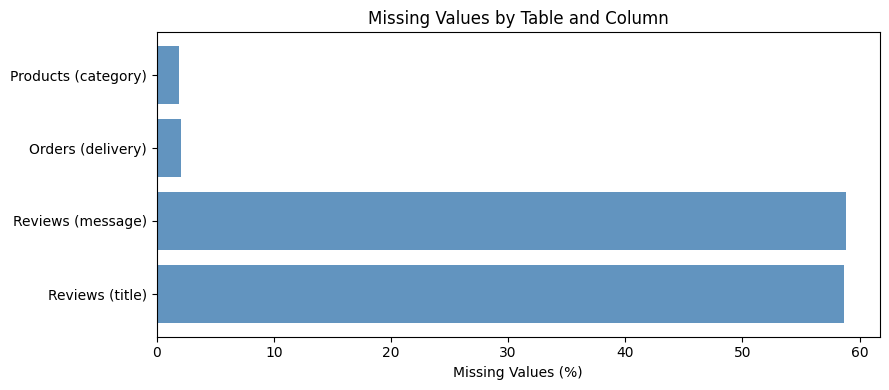

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

missing_summary = pd.DataFrame({
    'Table': ['Customers', 'Geolocation', 'Order Items', 'Payments',
               'Reviews (title)', 'Reviews (message)', 'Orders (delivery)', 'Products (category)', 'Sellers'],
    'Missing (%)': [0.0, 0.0, 0.0, 0.0, 58.7, 58.8, 2.1, 1.9, 0.0]
})

missing_summary = missing_summary[missing_summary['Missing (%)'] > 0]

plt.figure(figsize=(9, 4))
plt.barh(missing_summary['Table'], missing_summary['Missing (%)'], color='steelblue', alpha=0.85)
plt.xlabel('Missing Values (%)')
plt.title('Missing Values by Table and Column')
plt.tight_layout()
plt.savefig('results/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()


### 2. Order Status Distribution

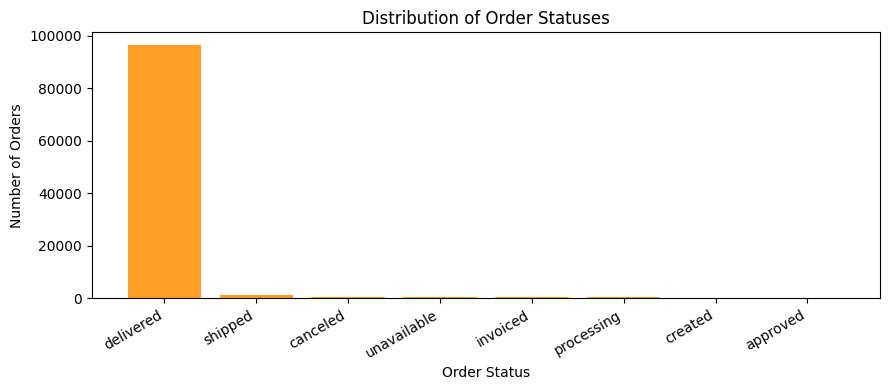

In [48]:
status_counts = df_Order['order_status'].value_counts()

plt.figure(figsize=(9, 4))
plt.bar(status_counts.index, status_counts.values, color='darkorange', alpha=0.85)
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Statuses')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('results/order_status.png', dpi=300, bbox_inches='tight')
plt.show()


### 3. Review Score Distribution

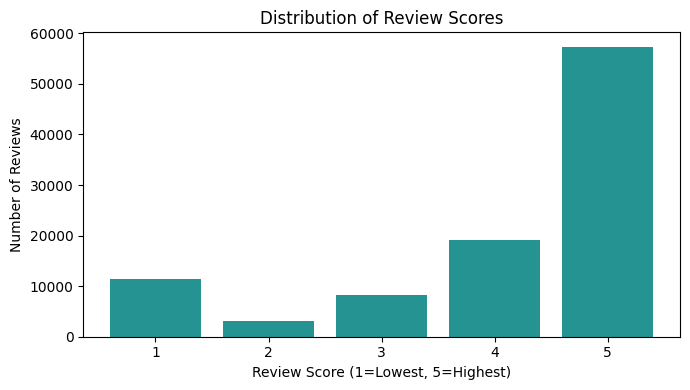

In [49]:
# reload original reviews before the drop
df_reviews_raw = pd.read_csv('olist/olist_order_reviews_dataset.csv')

score_counts = df_reviews_raw['review_score'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(score_counts.index, score_counts.values, color='teal', alpha=0.85)
plt.xlabel('Review Score (1=Lowest, 5=Highest)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Scores')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('results/review_scores.png', dpi=300, bbox_inches='tight')
plt.show()


### 4. Payment Type Distribution

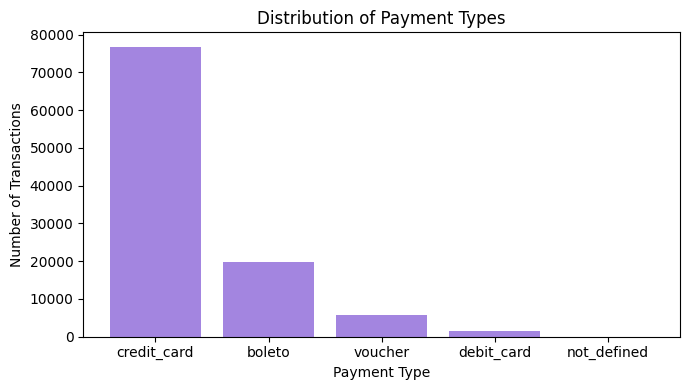

In [51]:
payment_counts = df_OrderPayments['payment_type'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(payment_counts.index, payment_counts.values, color='mediumpurple', alpha=0.85)
plt.xlabel('Payment Type')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Payment Types')
plt.tight_layout()
plt.savefig('results/payment_types.png', dpi=300, bbox_inches='tight')
plt.show()


### 5. RFM Distributions

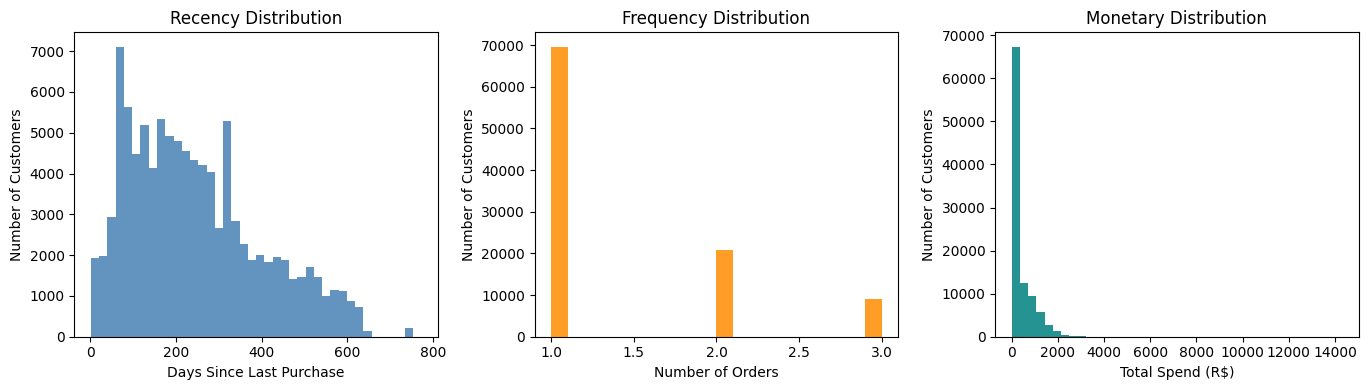

In [52]:
import os
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rfm['recency'], bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['frequency'], bins=20, color='darkorange', alpha=0.85)
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['monetary'], bins=40, color='teal', alpha=0.85)
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (R$)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('results/rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
